<a href="https://colab.research.google.com/github/EA88837/Siamese-Networks-for-Image-Similarity-Task/blob/main/pgmprojectMINST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [205]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

# Install pgmpy library if not already installed
!pip install pgmpy
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination
from tensorflow.keras.datasets import mnist

# Set Seaborn style and palette for attractive plots
sns.set_style("whitegrid")
sns.set_palette("viridis")

# --- 1. Data Loading and Feature Extraction (Re-run from 3bd4084c) ---

# Load and preprocess MNIST dataset (training and test splits)
(x_train_full, y_train_full), (x_test, y_test) = mnist.load_data()
x_test = x_test.astype("float32") / 255.0 # Normalize pixel values to [0, 1]
x_test = np.expand_dims(x_test, -1) # Reshape for compatibility with CNN (add channel dimension)

# Define a function to extract quadrant features from an image
def extract_quadrant_features(image):
    h, w = image.shape[0], image.shape[1]
    h_half, w_half = h // 2, w // 2
    top_left = image[0:h_half, 0:w_half]
    top_right = image[0:h_half, w_half:w]
    bottom_left = image[h_half:h, 0:w_half]
    bottom_right = image[h_half:h, w_half:w]
    features = {
        'TL': np.mean(top_left), # Mean intensity of top-left quadrant
        'TR': np.mean(top_right), # Mean intensity of top-right quadrant
        'BL': np.mean(bottom_left), # Mean intensity of bottom-left quadrant
        'BR': np.mean(bottom_right) # Mean intensity of bottom-right quadrant
    }
    return features

np.random.seed(42) # Set random seed for reproducibility
sample_indices = np.random.choice(len(x_test), 1000, replace=False) # Select a random subset of 1000 test images
x_test_subset = x_test[sample_indices]
y_test_subset = y_test[sample_indices]

# Extract quadrant features for each image in the subset
raw_features = []
for img in x_test_subset:
    raw_features.append(extract_quadrant_features(img.squeeze()))
raw_features_df = pd.DataFrame(raw_features) # Convert extracted features to a DataFrame

In [206]:
# --- 2. Discretization (Modified for 5 bins) ---

# Function to discretize a continuous feature value into one of 5 bins
def discretize_feature(value, feature_name, quantiles_df):
    # Using 5 bins: 'very_low', 'low', 'medium', 'high', 'very_high'
    q20 = quantiles_df.loc[0.20, feature_name]
    q40 = quantiles_df.loc[0.40, feature_name]
    q60 = quantiles_df.loc[0.60, feature_name]
    q80 = quantiles_df.loc[0.80, feature_name]

    if value <= q20:
        return 'very_low'
    elif value <= q40:
        return 'low'
    elif value <= q60:
        return 'medium'
    elif value <= q80:
        return 'high'
    else:
        return 'very_high'

# Calculate quintiles (20th, 40th, 60th, 80th percentiles) for each raw feature
quantiles_df = raw_features_df.quantile([0.20, 0.40, 0.60, 0.80])

# Apply discretization to all raw features
discrete_features = raw_features_df.copy()
for col in raw_features_df.columns:
    discrete_features[col] = raw_features_df[col].apply(lambda x: discretize_feature(x, col, quantiles_df))
discrete_features_df = discrete_features

In [207]:
# --- 3. Combine Discretized Features and Labels (Re-run from 0eca586b) ---

# Create a DataFrame for the digit labels
labels_df = pd.DataFrame(y_test_subset, columns=['digit_label'])
# Concatenate discrete features and digit labels into a single DataFrame for PGM
pgm_data_df = pd.concat([discrete_features_df, labels_df], axis=1)

In [208]:
# --- 4. Build Bayesian Network Structure (Re-run from 89a4152b) ---

# Define the structure of the Bayesian Network: digit_label influences all four quadrants
bn_model = DiscreteBayesianNetwork([
    ('digit_label', 'TL'), # digit_label influences Top-Left quadrant
    ('digit_label', 'TR'), # digit_label influences Top-Right quadrant
    ('digit_label', 'BL'), # digit_label influences Bottom-Left quadrant
    ('digit_label', 'BR')  # digit_label influences Bottom-Right quadrant
])

In [209]:
# --- 5. Define Conditional Probability Distributions (CPDs) (Modified for 5 bins) ---

quadrant_cardinality = 5 # Number of bins for discretized quadrant features
quadrant_categories = ['very_low', 'low', 'medium', 'high', 'very_high'] # Names of the bins
digit_label_cardinality = 10 # Number of possible digit labels (0-9)

# Calculate prior probabilities for each digit label
digit_counts = pgm_data_df['digit_label'].value_counts().sort_index()
digit_probabilities = digit_counts.values / len(pgm_data_df)
digit_probabilities_2d = digit_probabilities.reshape(-1, 1)

# Create CPD for the 'digit_label' (prior distribution)
cpd_digit_label = TabularCPD(
    variable='digit_label',
    variable_card=digit_label_cardinality,
    values=digit_probabilities_2d
)

cpd_quadrants = []
category_map = {cat: i for i, cat in enumerate(quadrant_categories)} # Map category names to numerical indices

# Create CPDs for each quadrant feature given the digit_label
for quadrant_feature in ['TL', 'TR', 'BL', 'BR']:
    values = np.zeros((quadrant_cardinality, digit_label_cardinality))

    for digit in range(digit_label_cardinality):
        digit_data = pgm_data_df[pgm_data_df['digit_label'] == digit] # Filter data for the current digit
        if not digit_data.empty:
            quadrant_counts = digit_data[quadrant_feature].value_counts() # Count occurrences of each quadrant category for the digit
            for category, count in quadrant_counts.items():
                if category in category_map:
                    values[category_map[category], digit] = count / len(digit_data) # Calculate conditional probability
            col_sum = np.sum(values[:, digit])
            # Ensure probabilities sum to 1 for each digit column (marginalizing over quadrant categories)
            if col_sum > 0:
                values[:, digit] /= col_sum

    cpd = TabularCPD(
        variable=quadrant_feature,
        variable_card=quadrant_cardinality,
        values=values,
        evidence=['digit_label'],
        evidence_card=[digit_label_cardinality],
        state_names={
            quadrant_feature: quadrant_categories, # Assign human-readable state names for quadrants
            'digit_label': list(range(digit_label_cardinality))
        }
    )
    cpd_quadrants.append(cpd)
bn_model.add_cpds(cpd_digit_label, *cpd_quadrants) # Add all CPDs to the Bayesian Network model

# Check if the model is consistent after adding all CPDs
print("\nModel is consistent after adding all CPDs:", bn_model.check_model())


Model is consistent after adding all CPDs: True


In [210]:
# --- 6. Perform Inference (Re-run with new CPDs) ---

# Initialize the VariableElimination inference algorithm for the Bayesian Network
infer = VariableElimination(bn_model)

# Select a test image that was not part of the PGM training data to avoid data leakage
all_test_indices = set(range(len(x_test)))
pgm_train_indices = set(sample_indices)
available_test_indices = list(all_test_indices - pgm_train_indices)

if not available_test_indices:
    test_img_idx = np.random.choice(len(x_test))
else:
    test_img_idx = np.random.choice(available_test_indices)

query_image_pgm = x_test[test_img_idx]
true_label_pgm = y_test[test_img_idx]
raw_features_pgm = extract_quadrant_features(query_image_pgm.squeeze())

# Discretize the raw quadrant features of the selected test image
discrete_features_pgm = {}
for feature_name, value in raw_features_pgm.items():
    discrete_features_pgm[feature_name] = discretize_feature(value, feature_name, quantiles_df)

# Perform inference to predict the digit label based on the discretized features
query_result = infer.query(variables=['digit_label'], evidence=discrete_features_pgm)
predicted_label_pgm = query_result.values.argmax() # Get the label with the highest probability

print(f"\nSelected test image index: {test_img_idx}")
print(f"True Label: {true_label_pgm}")
print(f"Raw Quadrant Features: {raw_features_pgm}")
print(f"Discretized Quadrant Features: {discrete_features_pgm}")
print(f"Predicted Label: {predicted_label_pgm}")
print("\nProbability distribution over digit_label:")
print(query_result)


Selected test image index: 1950
True Label: 7
Raw Quadrant Features: {'TL': np.float32(0.101700686), 'TR': np.float32(0.10572229), 'BL': np.float32(0.0232493), 'BR': np.float32(0.12773108)}
Discretized Quadrant Features: {'TL': 'medium', 'TR': 'low', 'BL': 'very_low', 'BR': 'low'}
Predicted Label: 7

Probability distribution over digit_label:
+----------------+--------------------+
| digit_label    |   phi(digit_label) |
+================+====================+
| digit_label(0) |             0.0000 |
+----------------+--------------------+
| digit_label(1) |             0.0517 |
+----------------+--------------------+
| digit_label(2) |             0.0123 |
+----------------+--------------------+
| digit_label(3) |             0.0497 |
+----------------+--------------------+
| digit_label(4) |             0.2363 |
+----------------+--------------------+
| digit_label(5) |             0.0410 |
+----------------+--------------------+
| digit_label(6) |             0.0027 |
+-------------

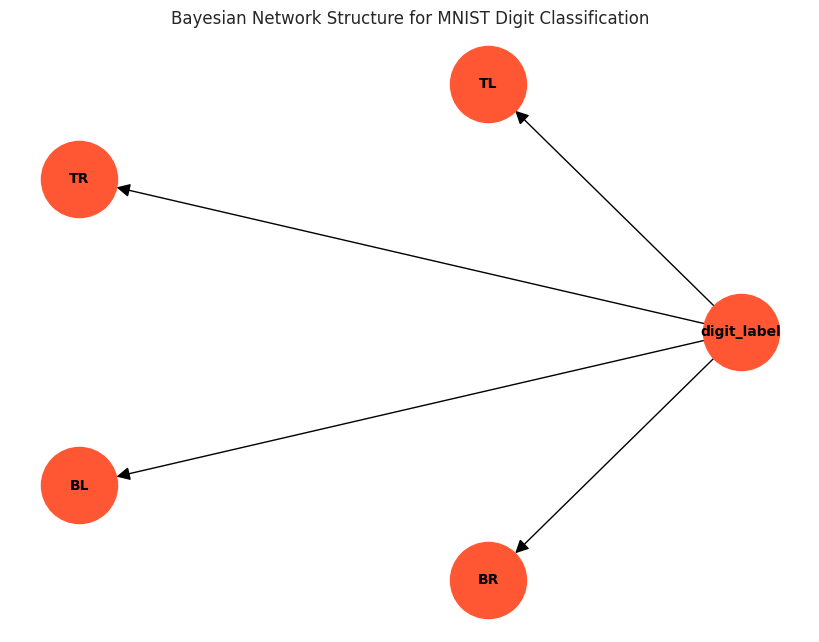

In [211]:
# --- 7. Bayesian Network Structure Visualization ---

plt.figure(figsize=(8, 6)) # Create a figure for the plot
pos = nx.circular_layout(bn_model) # Arrange nodes in a circular layout
nx.draw(bn_model, pos=pos, with_labels=True, node_size=3000, node_color='#FF5733', font_size=10, font_weight='bold', arrowsize=20) # Draw the Bayesian Network graph
plt.title("Bayesian Network Structure for MNIST Digit Classification") # Set the title of the plot
plt.show() # Display the plot

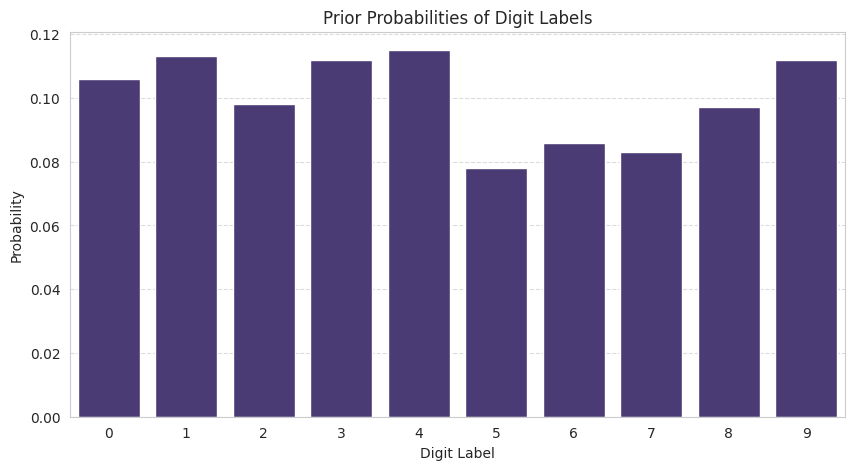

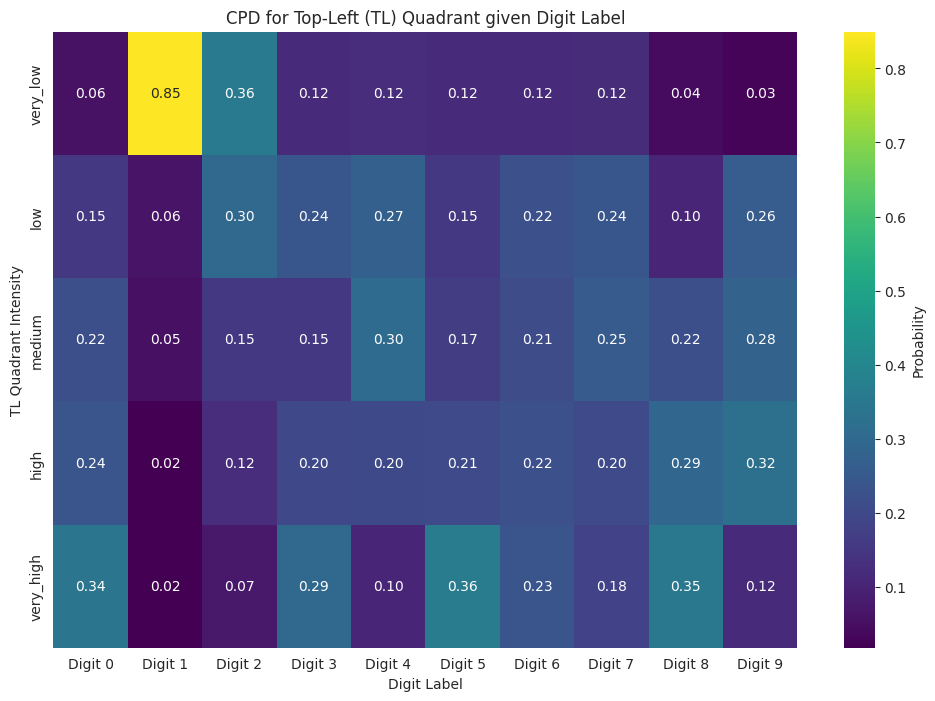

In [212]:
# --- 8. Conditional Probability Distribution (CPD) Visualizations ---

# Visualize CPD for digit_label (prior probabilities)
plt.figure(figsize=(10, 5))
sns.barplot(x=list(range(digit_label_cardinality)), y=cpd_digit_label.values.flatten()) # Create a bar plot of prior probabilities
plt.title("Prior Probabilities of Digit Labels") # Set plot title
plt.xlabel("Digit Label") # Set x-axis label
plt.ylabel("Probability") # Set y-axis label
plt.xticks(rotation=0) # Ensure x-axis labels are horizontal
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a horizontal grid
plt.show() # Display the plot

# Visualize CPD for TL given digit_label as a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    cpd_quadrants[0].values, # Assuming cpd_quadrants[0] is for 'TL' (Top-Left quadrant)
    xticklabels=[f'Digit {i}' for i in range(digit_label_cardinality)], # X-axis labels for digit classes
    yticklabels=quadrant_categories, # Y-axis labels for quadrant categories
    annot=True, fmt=".2f", cmap="viridis", cbar_kws={'label': 'Probability'} # Add annotations, format, colormap, and colorbar label
)
plt.title("CPD for Top-Left (TL) Quadrant given Digit Label") # Set plot title
plt.xlabel("Digit Label") # Set x-axis label
plt.ylabel("TL Quadrant Intensity") # Set y-axis label
plt.show() # Display the plot

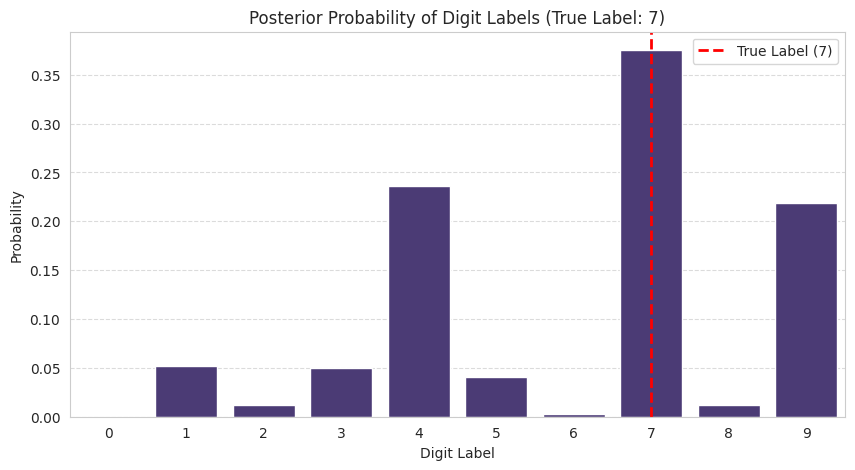

In [213]:
# --- 9. Inference Result Visualization ---

plt.figure(figsize=(10, 5)) # Create a figure for the plot
sns.barplot(x=list(range(digit_label_cardinality)), y=query_result.values.flatten()) # Create a bar plot of posterior probabilities
plt.title(f"Posterior Probability of Digit Labels (True Label: {true_label_pgm})") # Set plot title including true label
plt.xlabel("Digit Label") # Set x-axis label
plt.ylabel("Probability") # Set y-axis label
plt.xticks(rotation=0) # Ensure x-axis labels are horizontal
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a horizontal grid

plt.axvline(x=true_label_pgm, color='red', linestyle='--', linewidth=2, label=f'True Label ({true_label_pgm})') # Add a vertical line for the true label
plt.legend() # Display the legend
plt.show() # Display the plot

In [214]:
from sklearn.metrics import confusion_matrix

# Generate predictions for the test subset
pgm_predictions = []
pgm_true_labels = []

# We will use the x_test_subset and y_test_subset that were already created for PGM training.
# If you wish to use a completely separate test set, you would need to load and preprocess it here.

print("Generating PGM predictions for the test subset...")
for i, img_raw in enumerate(x_test_subset):
    # Extract and discretize features for the current image
    current_raw_features = extract_quadrant_features(img_raw.squeeze())
    current_discrete_features = {}
    for feature_name, value in current_raw_features.items():
        current_discrete_features[feature_name] = discretize_feature(value, feature_name, quantiles_df)

    # Perform inference using Variable Elimination to get predicted label
    query_result_subset = infer.query(variables=['digit_label'], evidence=current_discrete_features)
    predicted_label = query_result_subset.values.argmax()

    pgm_predictions.append(predicted_label)
    pgm_true_labels.append(y_test_subset[i])

print("Predictions generated. Calculating confusion matrix...")

# Calculate the confusion matrix
cm = confusion_matrix(pgm_true_labels, pgm_predictions, labels=range(digit_label_cardinality))

# Print classification report for more detailed metrics (optional)
from sklearn.metrics import classification_report
print("\nClassification Report:")
print(classification_report(pgm_true_labels, pgm_predictions, target_names=[str(i) for i in range(digit_label_cardinality)]))

print("Confusion Matrix:")
print(cm)

Generating PGM predictions for the test subset...
Predictions generated. Calculating confusion matrix...

Classification Report:
              precision    recall  f1-score   support

           0       0.35      0.67      0.46       106
           1       0.55      0.81      0.65       113
           2       0.38      0.34      0.36        98
           3       0.33      0.16      0.22       112
           4       0.28      0.34      0.31       115
           5       0.25      0.05      0.09        78
           6       0.55      0.31      0.40        86
           7       0.31      0.19      0.24        83
           8       0.36      0.22      0.27        97
           9       0.28      0.45      0.34       112

    accuracy                           0.37      1000
   macro avg       0.36      0.35      0.33      1000
weighted avg       0.36      0.37      0.34      1000

Confusion Matrix:
[[71  6  8  1  5  3  1  0  2  9]
 [ 0 91  7  1 11  2  0  0  0  1]
 [23 16 33  0 12  0  2  2  3

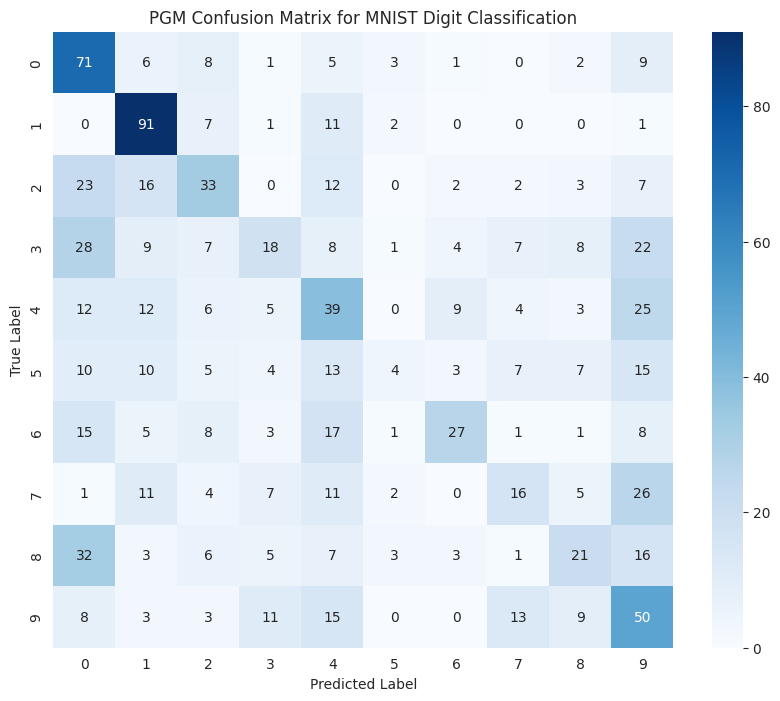

In [215]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the confusion matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(digit_label_cardinality),
            yticklabels=range(digit_label_cardinality))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('PGM Confusion Matrix for MNIST Digit Classification')
plt.show()

Generating PGM prediction probabilities for ROC analysis...


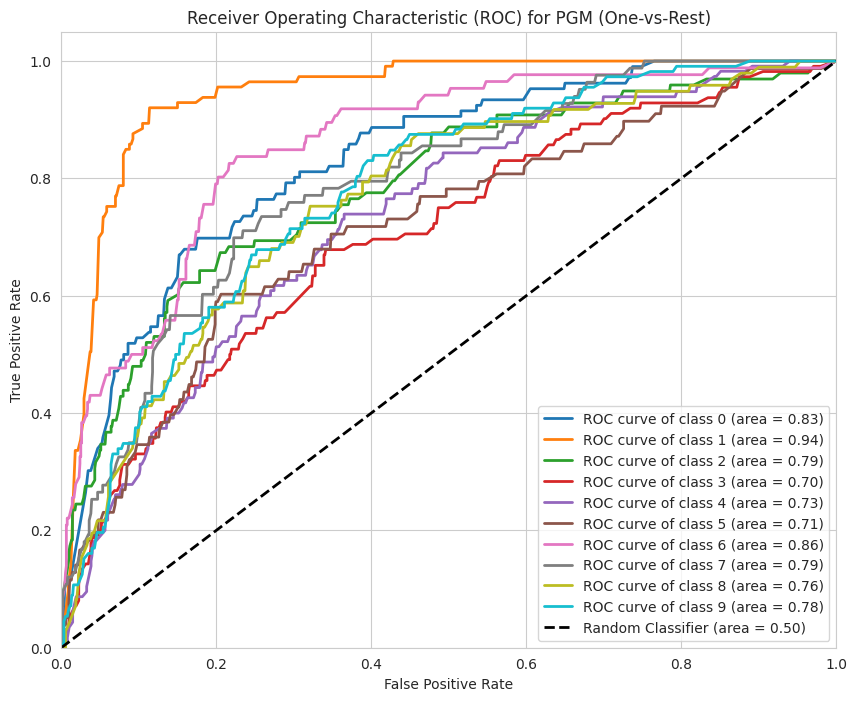

AUC for each class:
Class 0: 0.83
Class 1: 0.94
Class 2: 0.79
Class 3: 0.70
Class 4: 0.73
Class 5: 0.71
Class 6: 0.86
Class 7: 0.79
Class 8: 0.76
Class 9: 0.78


In [216]:
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import roc_curve, auc

# Re-generate predictions to get probabilities for each class (needed for ROC curve)
pgm_pred_probs = []

print("Generating PGM prediction probabilities for ROC analysis...")
for i, img_raw in enumerate(x_test_subset):
    current_raw_features = extract_quadrant_features(img_raw.squeeze())
    current_discrete_features = {}
    for feature_name, value in current_raw_features.items():
        current_discrete_features[feature_name] = discretize_feature(value, feature_name, quantiles_df)

    # Perform inference to get probability distribution over digit_label
    query_result_subset = infer.query(variables=['digit_label'], evidence=current_discrete_features)
    pgm_pred_probs.append(query_result_subset.values.flatten())

pgm_pred_probs = np.array(pgm_pred_probs)

# Binarize the true labels for one-vs-rest ROC calculation
label_binarizer = LabelBinarizer()
y_true_binarized = label_binarizer.fit_transform(pgm_true_labels)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

plt.figure(figsize=(10, 8))
# Get a distinct color palette for the ROC curves
colors = sns.color_palette('tab10', digit_label_cardinality) # Changed palette to 'tab10'

for i in range(digit_label_cardinality):
    # Ensure we have probabilities for the current class
    if pgm_pred_probs.shape[1] > i:
        fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], pgm_pred_probs[:, i]) # Calculate FPR, TPR
        roc_auc[i] = auc(fpr[i], tpr[i]) # Calculate AUC
        plt.plot(fpr[i], tpr[i], lw=2, label=f'ROC curve of class {i} (area = {roc_auc[i]:.2f})', color=colors[i]) # Plot ROC curve

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier (area = 0.50)') # Plot random classifier baseline
plt.xlim([0.0, 1.0]) # Set x-axis limits
plt.ylim([0.0, 1.05]) # Set y-axis limits
plt.xlabel('False Positive Rate') # Set x-axis label
plt.ylabel('True Positive Rate') # Set y-axis label
plt.title('Receiver Operating Characteristic (ROC) for PGM (One-vs-Rest)') # Set plot title
plt.legend(loc="lower right") # Display legend
plt.grid(True) # Add grid
plt.show() # Display the plot

print("AUC for each class:")
for i in range(digit_label_cardinality):
    if i in roc_auc:
        print(f"Class {i}: {roc_auc[i]:.2f}")

## 13. Comparison with Other ML Models: Logistic Regression

To provide context for the PGM's performance, let's compare it with a simpler, widely used machine learning model: Logistic Regression. We will use the same raw quadrant features and digit labels.

In [217]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# Prepare data for Logistic Regression using the same features and labels as PGM
# We'll use the raw_features_df (X) and y_test_subset (y) (our sampled data)

X = raw_features_df.values # Features (raw quadrant mean intensities)
y = y_test_subset # Labels (true digit labels)

# For simplicity and direct comparison with PGM on the same subset, we'll train on the full subset
# In a real scenario, you'd split this into train/validation/test sets.

print(f"Shape of features for LR: {X.shape}")
print(f"Shape of labels for LR: {y.shape}")

Shape of features for LR: (1000, 4)
Shape of labels for LR: (1000,)


### Training Logistic Regression Model

We will train a Logistic Regression classifier on the raw quadrant features. Given the small number of features, we might not need extensive hyperparameter tuning for a baseline comparison.

In [218]:
log_reg_model = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs', multi_class='multinomial') # Initialize Logistic Regression model

log_reg_model.fit(X, y) # Train the Logistic Regression model on the data

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


### Evaluating Logistic Regression Performance

Now, let's evaluate the Logistic Regression model using the same metrics as the PGM: classification report, confusion matrix, and ROC AUC.


Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.73      0.45       106
           1       0.32      0.94      0.48       113
           2       0.69      0.20      0.31        98
           3       0.26      0.29      0.28       112
           4       0.24      0.43      0.31       115
           5       0.00      0.00      0.00        78
           6       0.67      0.02      0.04        86
           7       0.00      0.00      0.00        83
           8       0.00      0.00      0.00        97
           9       0.26      0.18      0.21       112

    accuracy                           0.31      1000
   macro avg       0.28      0.28      0.21      1000
weighted avg       0.28      0.31      0.23      1000


Logistic Regression Confusion Matrix:
[[ 77  15   0   4   8   0   0   0   0   2]
 [  1 106   0   1   5   0   0   0   0   0]
 [ 28  29  20   5  16   0   0   0   0   0]
 [ 28  26   1  33  16   0   0

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


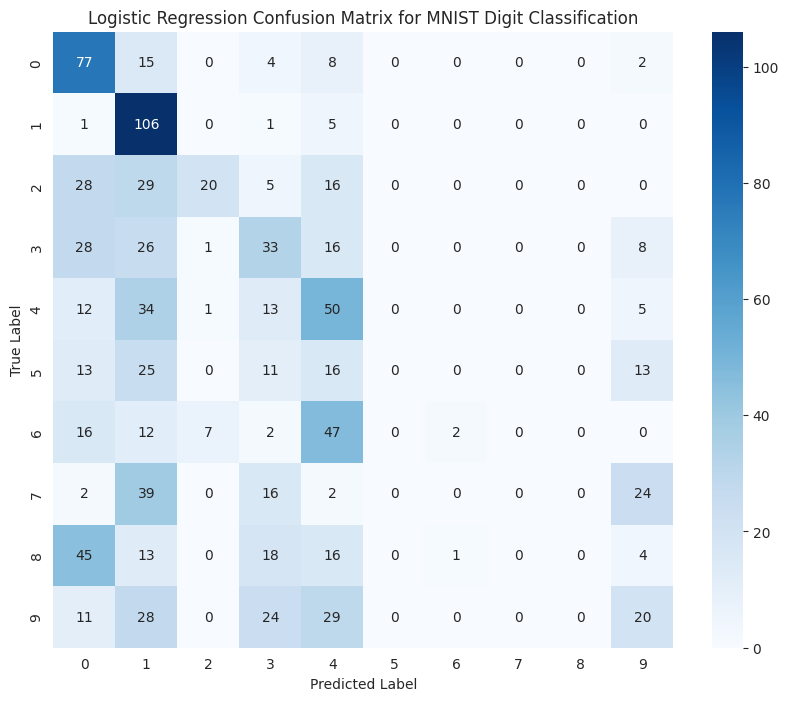

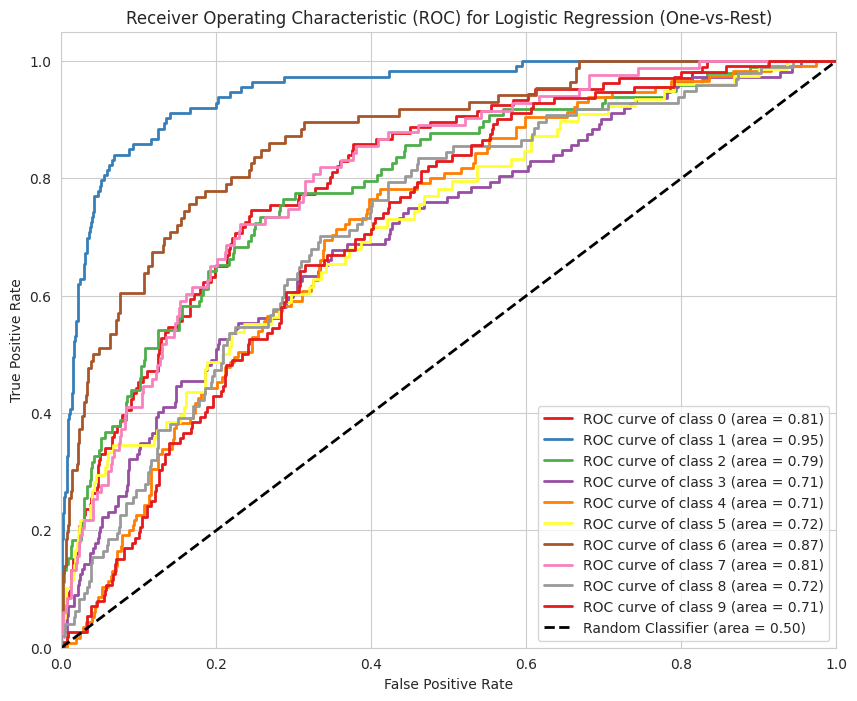


AUC for each class (Logistic Regression):
Class 0: 0.81
Class 1: 0.95
Class 2: 0.79
Class 3: 0.71
Class 4: 0.71
Class 5: 0.72
Class 6: 0.87
Class 7: 0.81
Class 8: 0.72
Class 9: 0.71


In [219]:
# Make predictions and get probabilities from the trained Logistic Regression model
log_reg_predictions = log_reg_model.predict(X)
log_reg_pred_probs = log_reg_model.predict_proba(X)

# Print Classification Report for Logistic Regression
print("\nLogistic Regression Classification Report:")
print(classification_report(y, log_reg_predictions, target_names=[str(i) for i in range(digit_label_cardinality)]))

# Calculate and print Confusion Matrix for Logistic Regression
log_reg_cm = confusion_matrix(y, log_reg_predictions, labels=range(digit_label_cardinality))
print("\nLogistic Regression Confusion Matrix:")
print(log_reg_cm)

# Visualize the Confusion Matrix for Logistic Regression
plt.figure(figsize=(10, 8))
sns.heatmap(log_reg_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(digit_label_cardinality),
            yticklabels=range(digit_label_cardinality))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Logistic Regression Confusion Matrix for MNIST Digit Classification')
plt.show()

# Calculate and plot ROC AUC for Logistic Regression (One-vs-Rest)
y_binarized_lr = label_binarize(y, classes=range(digit_label_cardinality))

fpr_lr = dict()
tpr_lr = dict()
roc_auc_lr = dict()

plt.figure(figsize=(10, 8))
# Get a distinct color palette for the ROC curves
colors_lr = sns.color_palette('Set1', digit_label_cardinality) # Changed palette to 'Set1'

for i in range(digit_label_cardinality):
    fpr_lr[i], tpr_lr[i], _ = roc_curve(y_binarized_lr[:, i], log_reg_pred_probs[:, i]) # Calculate FPR, TPR
    roc_auc_lr[i] = auc(fpr_lr[i], tpr_lr[i]) # Calculate AUC
    plt.plot(fpr_lr[i], tpr_lr[i], lw=2, label=f'ROC curve of class {i} (area = {roc_auc_lr[i]:.2f})', color=colors_lr[i]) # Plot ROC curve

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier (area = 0.50)') # Plot random classifier baseline
plt.xlim([0.0, 1.0]) # Set x-axis limits
plt.ylim([0.0, 1.05]) # Set y-axis limits
plt.xlabel('False Positive Rate') # Set x-axis label
plt.ylabel('True Positive Rate') # Set y-axis label
plt.title('Receiver Operating Characteristic (ROC) for Logistic Regression (One-vs-Rest)') # Set plot title
plt.legend(loc="lower right") # Display legend
plt.grid(True) # Add grid
plt.show() # Display the plot

print("\nAUC for each class (Logistic Regression):")
for i in range(digit_label_cardinality):
    print(f"Class {i}: {roc_auc_lr[i]:.2f}")

## 14. Comparison with Other ML Models: Support Vector Machine (SVM)

To further broaden our comparison, let's include a Support Vector Machine (SVM) classifier. We will use the same `raw_features_df` (X) and `y_test_subset` (y) data.

In [220]:
from sklearn.svm import SVC

# Initialize and train the SVM model with RBF kernel and probability estimates enabled
# Using 'rbf' kernel for non-linear decision boundaries, and a reasonable C value.
# probability=True is needed for ROC AUC calculation
svm_model = SVC(kernel='rbf', C=1.0, random_state=42, probability=True)

# Train the model on the same data used for Logistic Regression
svm_model.fit(X, y) # Train the SVM model on the features and labels

print("Support Vector Machine model trained successfully.")

Support Vector Machine model trained successfully.


### Evaluating Support Vector Machine Performance

Now, let's evaluate the SVM model using the same metrics: classification report, confusion matrix, and ROC AUC.


Support Vector Machine Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.69      0.60       106
           1       0.72      0.90      0.80       113
           2       0.59      0.61      0.60        98
           3       0.52      0.40      0.45       112
           4       0.42      0.44      0.43       115
           5       0.39      0.33      0.36        78
           6       0.70      0.49      0.58        86
           7       0.56      0.53      0.55        83
           8       0.45      0.33      0.38        97
           9       0.37      0.44      0.40       112

    accuracy                           0.52      1000
   macro avg       0.52      0.52      0.51      1000
weighted avg       0.52      0.52      0.52      1000


Support Vector Machine Confusion Matrix:
[[ 73   1   6   1   3   5   1   0  12   4]
 [  0 102   0   2   5   3   0   0   0   1]
 [  8   5  60   2  11   2   6   1   0   3]
 [  7   7   5  45   5  

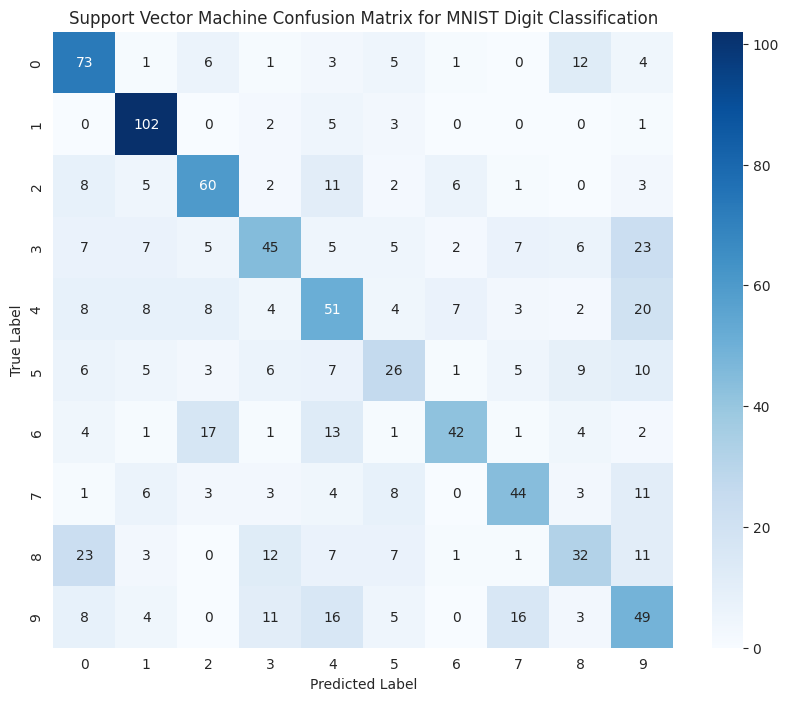

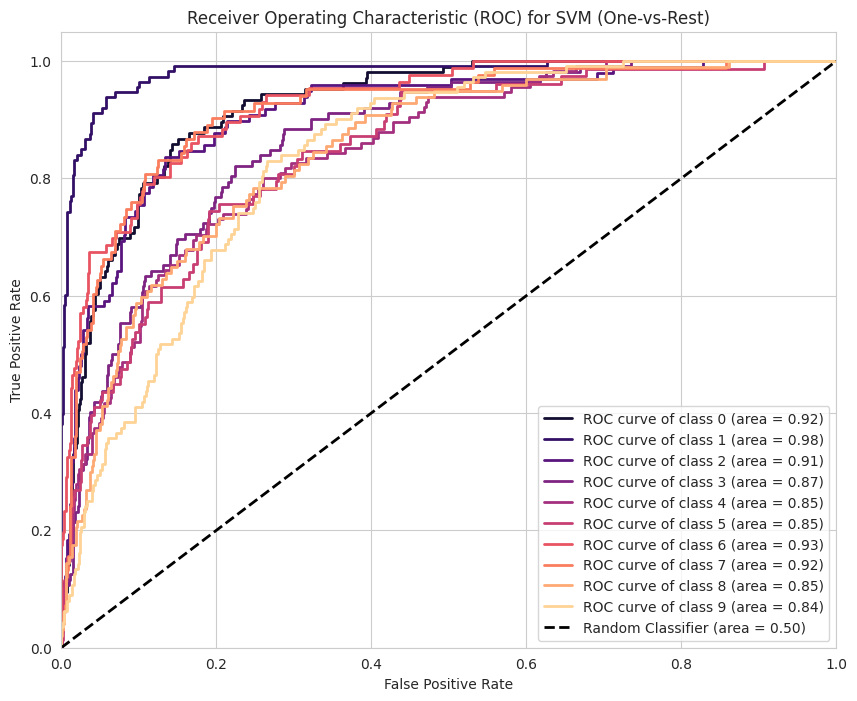


AUC for each class (Support Vector Machine):
Class 0: 0.92
Class 1: 0.98
Class 2: 0.91
Class 3: 0.87
Class 4: 0.85
Class 5: 0.85
Class 6: 0.93
Class 7: 0.92
Class 8: 0.85
Class 9: 0.84


In [221]:
# Make predictions and get probabilities from the trained SVM model
svm_predictions = svm_model.predict(X)
svm_pred_probs = svm_model.predict_proba(X)

# Print Classification Report for SVM
print("\nSupport Vector Machine Classification Report:")
print(classification_report(y, svm_predictions, target_names=[str(i) for i in range(digit_label_cardinality)]))

# Calculate and print Confusion Matrix for SVM
svm_cm = confusion_matrix(y, svm_predictions, labels=range(digit_label_cardinality))
print("\nSupport Vector Machine Confusion Matrix:")
print(svm_cm)

# Visualize the Confusion Matrix for SVM
plt.figure(figsize=(10, 8))
sns.heatmap(svm_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(digit_label_cardinality),
            yticklabels=range(digit_label_cardinality))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Support Vector Machine Confusion Matrix for MNIST Digit Classification')
plt.show()

# Calculate and plot ROC AUC for SVM (One-vs-Rest)
y_binarized_svm = label_binarize(y, classes=range(digit_label_cardinality))

fpr_svm = dict()
tpr_svm = dict()
roc_auc_svm = dict()

plt.figure(figsize=(10, 8))
# Get a distinct color palette for the ROC curves
colors_svm = sns.color_palette('magma', digit_label_cardinality)

for i in range(digit_label_cardinality):
    fpr_svm[i], tpr_svm[i], _ = roc_curve(y_binarized_svm[:, i], svm_pred_probs[:, i]) # Calculate FPR, TPR
    roc_auc_svm[i] = auc(fpr_svm[i], tpr_svm[i]) # Calculate AUC
    plt.plot(fpr_svm[i], tpr_svm[i], lw=2, label=f'ROC curve of class {i} (area = {roc_auc_svm[i]:.2f})', color=colors_svm[i]) # Plot ROC curve

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier (area = 0.50)') # Plot random classifier baseline
plt.xlim([0.0, 1.0]) # Set x-axis limits
plt.ylim([0.0, 1.05]) # Set y-axis limits
plt.xlabel('False Positive Rate') # Set x-axis label
plt.ylabel('True Positive Rate') # Set y-axis label
plt.title('Receiver Operating Characteristic (ROC) for SVM (One-vs-Rest)') # Set plot title
plt.legend(loc="lower right") # Display legend
plt.grid(True) # Add grid
plt.show() # Display the plot

print("\nAUC for each class (Support Vector Machine):")
for i in range(digit_label_cardinality):
    print(f"Class {i}: {roc_auc_svm[i]:.2f}")

### Comparison of PGM vs. Logistic Regression

Now that we have the evaluation metrics for both the PGM and Logistic Regression, we can compare their performance. Look at the accuracy, precision, recall, F1-score, and AUC for each class to identify which model performs better for this specific task and feature set. This comparison highlights the trade-offs and strengths of each approach.

### Visualizing the Comparison

Let's create some visualizations to clearly compare the performance of the Probabilistic Graphical Model (PGM) and Logistic Regression.

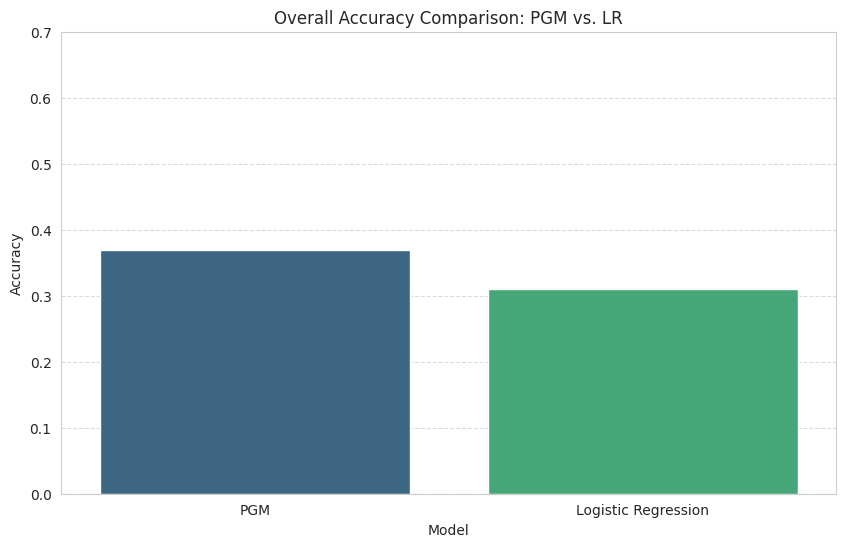

In [222]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Compare Overall Accuracy ---

# Extract accuracies from previous outputs (PGM and Logistic Regression)
# PGM accuracy from Classification Report: accuracy 0.37
pgm_accuracy = 0.37
# Logistic Regression accuracy from Classification Report: accuracy 0.31
log_reg_accuracy = 0.31

# Create a DataFrame for accuracy comparison
accuracy_df = pd.DataFrame({
    'Model': ['PGM', 'Logistic Regression'],
    'Accuracy': [pgm_accuracy, log_reg_accuracy]
})

# Plot overall accuracy comparison using a bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', hue='Model', data=accuracy_df, palette='viridis', legend=False)
plt.title('Overall Accuracy Comparison: PGM vs. LR')
plt.ylabel('Accuracy')
plt.ylim(0, 0.7) # Adjust y-limit to better show differences
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

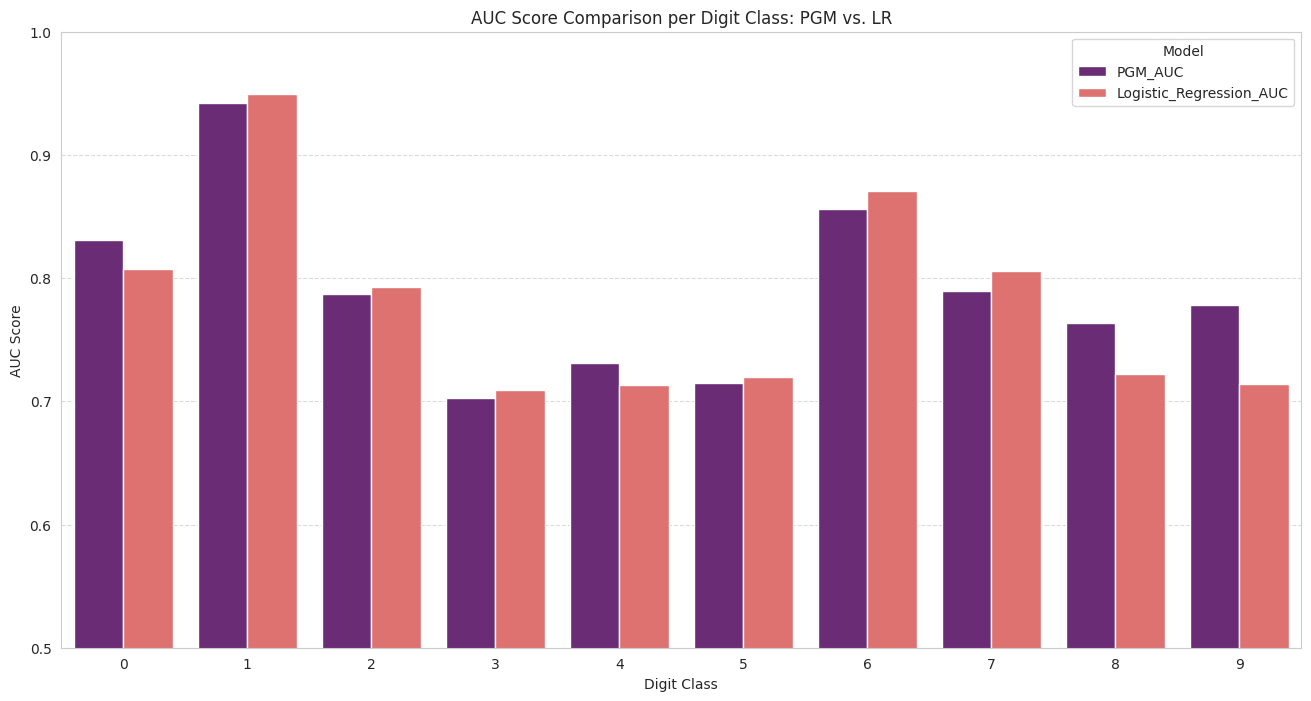

In [223]:
# --- 2. Compare AUC Scores per Class ---

# Extract AUCs from previous outputs (PGM and Logistic Regression)
# PGM AUCs (from 'roc_auc' dictionary)
pgm_auc = [
    roc_auc[0], roc_auc[1], roc_auc[2], roc_auc[3], roc_auc[4],
    roc_auc[5], roc_auc[6], roc_auc[7], roc_auc[8], roc_auc[9]
]

# Logistic Regression AUCs (from 'roc_auc_lr' dictionary)
log_reg_auc = [
    roc_auc_lr[0], roc_auc_lr[1], roc_auc_lr[2], roc_auc_lr[3], roc_auc_lr[4],
    roc_auc_lr[5], roc_auc_lr[6], roc_auc_lr[7], roc_auc_lr[8], roc_auc_lr[9]
]

# Create a DataFrame for AUC comparison per digit class
auc_comparison_df = pd.DataFrame({
    'Digit Class': list(range(digit_label_cardinality)),
    'PGM_AUC': pgm_auc,
    'Logistic_Regression_AUC': log_reg_auc
})

# Melt the DataFrame for easier plotting with Seaborn
auc_melted_df = auc_comparison_df.melt(id_vars='Digit Class', var_name='Model', value_name='AUC')

# Plot AUC score comparison per digit class using a bar plot
plt.figure(figsize=(16, 8)) # Larger figure for more models
sns.barplot(x='Digit Class', y='AUC', hue='Model', data=auc_melted_df, palette='magma')
plt.title('AUC Score Comparison per Digit Class: PGM vs. LR')
plt.ylabel('AUC Score')
plt.xlabel('Digit Class')
plt.ylim(0.5, 1.0) # AUC typically ranges from 0.5 (random) to 1.0 (perfect)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Model')
plt.show()

Generating PGM predictions using Belief Propagation for the test subset...
Predictions generated with Belief Propagation. Calculating metrics...

PGM (Belief Propagation) Classification Report:
              precision    recall  f1-score   support

           0       0.35      0.67      0.46       106
           1       0.55      0.81      0.65       113
           2       0.38      0.34      0.36        98
           3       0.33      0.16      0.22       112
           4       0.28      0.34      0.31       115
           5       0.25      0.05      0.09        78
           6       0.55      0.31      0.40        86
           7       0.31      0.19      0.24        83
           8       0.36      0.22      0.27        97
           9       0.28      0.45      0.34       112

    accuracy                           0.37      1000
   macro avg       0.36      0.35      0.33      1000
weighted avg       0.36      0.37      0.34      1000


PGM (Belief Propagation) Confusion Matrix:
[[7

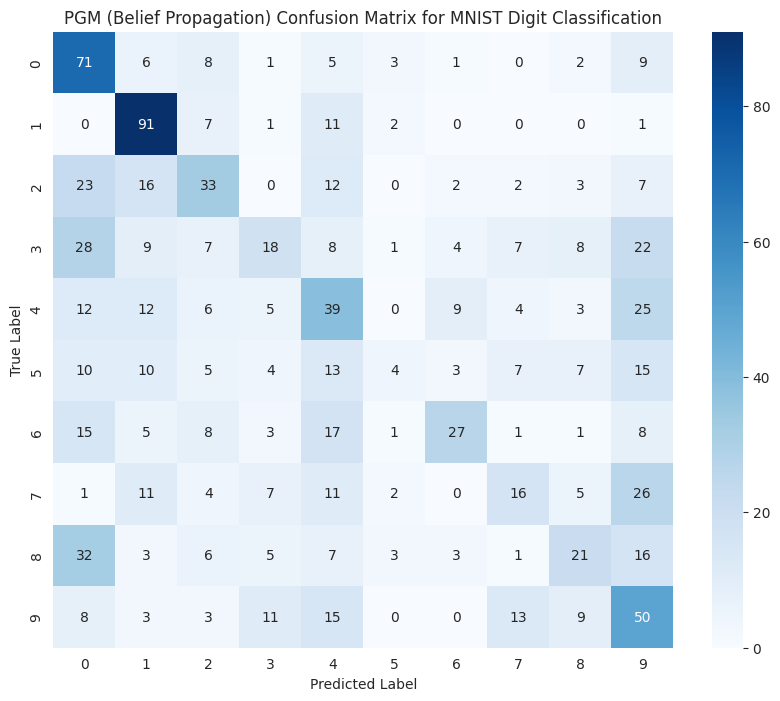

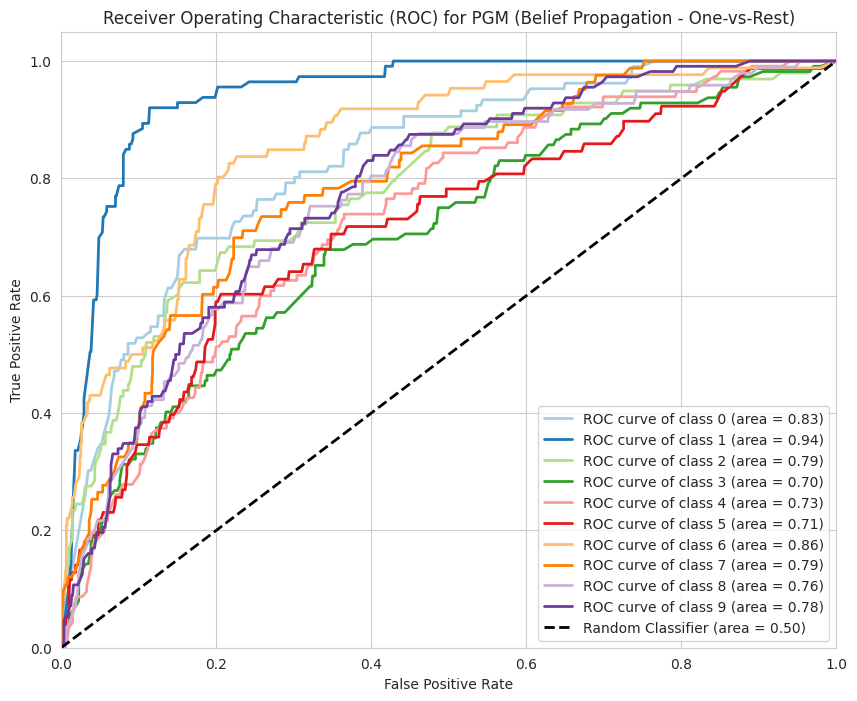


AUC for each class (PGM - Belief Propagation):
Class 0: 0.83
Class 1: 0.94
Class 2: 0.79
Class 3: 0.70
Class 4: 0.73
Class 5: 0.71
Class 6: 0.86
Class 7: 0.79
Class 8: 0.76
Class 9: 0.78


In [224]:
from pgmpy.inference import BeliefPropagation

# Initialize Belief Propagation inference object for the Bayesian Network
infer_bp = BeliefPropagation(bn_model)

print("Generating PGM predictions using Belief Propagation for the test subset...")
pgm_predictions_bp = []
pgm_pred_probs_bp = []

# Iterate through the test subset to make predictions using Belief Propagation
for i, img_raw in enumerate(x_test_subset):
    current_raw_features = extract_quadrant_features(img_raw.squeeze())
    current_discrete_features = {}
    for feature_name, value in current_raw_features.items():
        current_discrete_features[feature_name] = discretize_feature(value, feature_name, quantiles_df)

    # Perform inference using Belief Propagation to get predicted label and probabilities
    query_result_bp = infer_bp.query(variables=['digit_label'], evidence=current_discrete_features, show_progress=False)
    predicted_label_bp = query_result_bp.values.argmax()

    pgm_predictions_bp.append(predicted_label_bp)
    pgm_pred_probs_bp.append(query_result_bp.values.flatten())

pgm_pred_probs_bp = np.array(pgm_pred_probs_bp)

print("Predictions generated with Belief Propagation. Calculating metrics...")

# Print Classification Report for PGM (Belief Propagation)
print("\nPGM (Belief Propagation) Classification Report:")
print(classification_report(y_test_subset, pgm_predictions_bp, target_names=[str(i) for i in range(digit_label_cardinality)]))

# Calculate and print Confusion Matrix for PGM (Belief Propagation)
pgm_cm_bp = confusion_matrix(y_test_subset, pgm_predictions_bp, labels=range(digit_label_cardinality))
print("\nPGM (Belief Propagation) Confusion Matrix:")
print(pgm_cm_bp)

# Visualize the Confusion Matrix for PGM (Belief Propagation)
plt.figure(figsize=(10, 8))
sns.heatmap(pgm_cm_bp, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(digit_label_cardinality),
            yticklabels=range(digit_label_cardinality))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('PGM (Belief Propagation) Confusion Matrix for MNIST Digit Classification')
plt.show()

# Calculate and plot ROC AUC for PGM (Belief Propagation - One-vs-Rest)
y_true_binarized = label_binarizer.fit_transform(y_test_subset)

fpr_bp = dict()
tpr_bp = dict()
roc_auc_bp = dict()

plt.figure(figsize=(10, 8))
# Get a distinct color palette for the ROC curves
colors_bp = sns.color_palette('Paired', digit_label_cardinality) # Changed palette to 'Paired'

for i in range(digit_label_cardinality):
    if pgm_pred_probs_bp.shape[1] > i:
        fpr_bp[i], tpr_bp[i], _ = roc_curve(y_true_binarized[:, i], pgm_pred_probs_bp[:, i]) # Calculate FPR, TPR
        roc_auc_bp[i] = auc(fpr_bp[i], tpr_bp[i]) # Calculate AUC
        plt.plot(fpr_bp[i], tpr_bp[i], lw=2, label=f'ROC curve of class {i} (area = {roc_auc_bp[i]:.2f})', color=colors_bp[i]) # Plot ROC curve

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier (area = 0.50)') # Plot random classifier baseline
plt.xlim([0.0, 1.0]) # Set x-axis limits
plt.ylim([0.0, 1.05]) # Set y-axis limits
plt.xlabel('False Positive Rate') # Set x-axis label
plt.ylabel('True Positive Rate') # Set y-axis label
plt.title('Receiver Operating Characteristic (ROC) for PGM (Belief Propagation - One-vs-Rest)') # Set plot title
plt.legend(loc="lower right") # Display legend
plt.grid(True) # Add grid
plt.show() # Display the plot

print("\nAUC for each class (PGM - Belief Propagation):")
for i in range(digit_label_cardinality):
    if i in roc_auc_bp:
        print(f"Class {i}: {roc_auc_bp[i]:.2f}")

### Updating Comparison Visualizations with Belief Propagation Results

Now, let's update our overall accuracy and per-class AUC comparison plots to include the results obtained using Belief Propagation for the PGM.

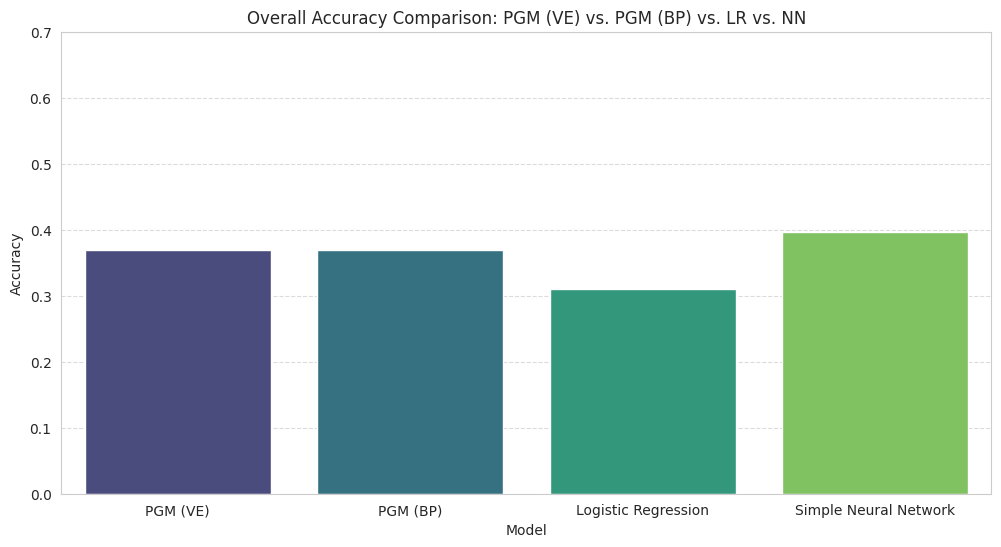

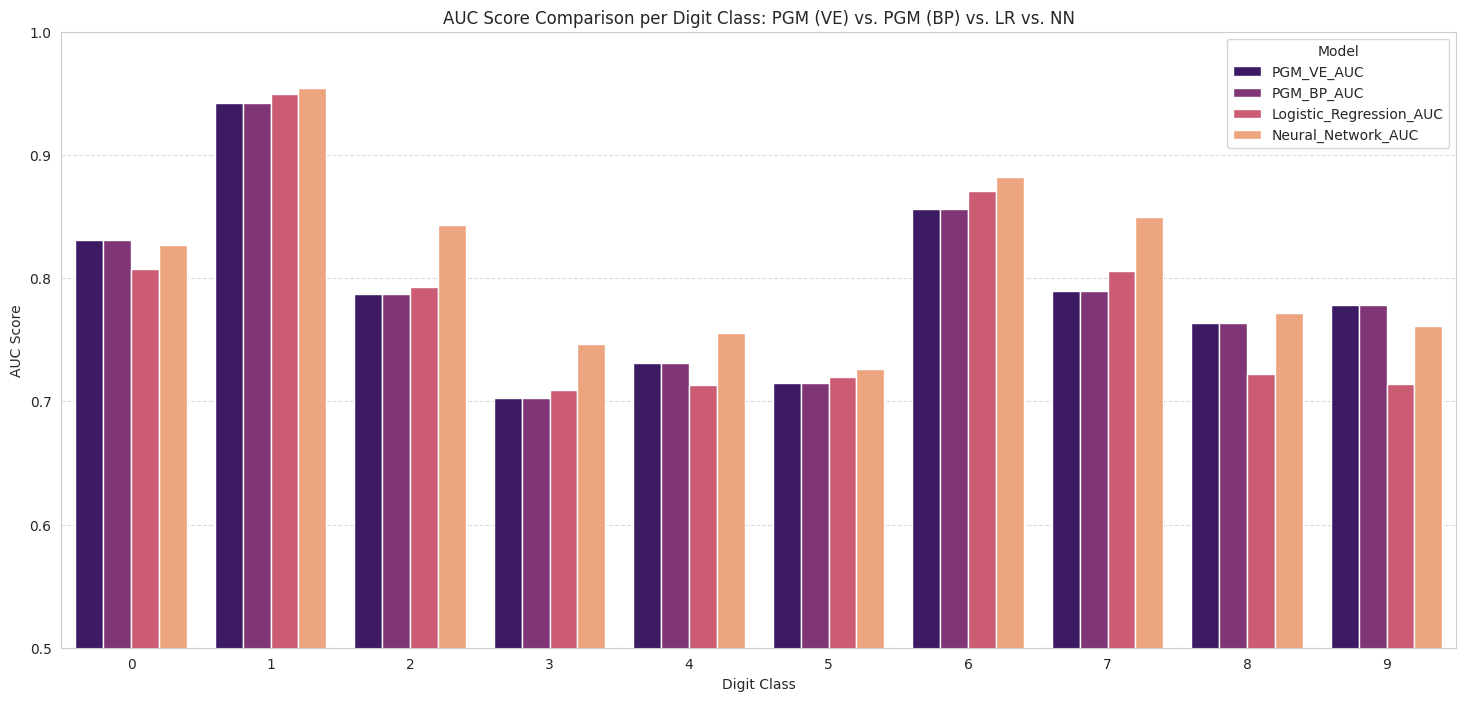

In [225]:
# Get accuracy from Classification Report for PGM (Variable Elimination)
from sklearn.metrics import classification_report
pgm_accuracy_report = classification_report(pgm_true_labels, pgm_predictions, output_dict=True)
pgm_accuracy = float(pgm_accuracy_report['accuracy'])

# Get accuracy from Classification Report for PGM (Belief Propagation)
pgm_bp_accuracy_report = classification_report(y_test_subset, pgm_predictions_bp, output_dict=True)
pgm_bp_accuracy = float(pgm_bp_accuracy_report['accuracy'])

# Get accuracy from Classification Report for Neural Network
nn_accuracy_report = classification_report(y_encoded, nn_predictions, output_dict=True)
nn_accuracy = float(nn_accuracy_report['accuracy'])

# Create an updated DataFrame for overall accuracy comparison including NN
accuracy_df_updated = pd.DataFrame({
    'Model': ['PGM (VE)', 'PGM (BP)', 'Logistic Regression', 'Simple Neural Network'],
    'Accuracy': [pgm_accuracy, pgm_bp_accuracy, log_reg_accuracy, nn_accuracy]
})

# Plot overall accuracy comparison
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='Accuracy', hue='Model', data=accuracy_df_updated, palette='viridis', legend=False)
plt.title('Overall Accuracy Comparison: PGM (VE) vs. PGM (BP) vs. LR vs. NN')
plt.ylabel('Accuracy')
plt.ylim(0, 0.7) # Adjust y-limit to better show differences
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Extract AUCs from previous outputs
# PGM AUCs (from 'roc_auc' dictionary for Variable Elimination)
pgm_auc = [
    roc_auc[0], roc_auc[1], roc_auc[2], roc_auc[3], roc_auc[4],
    roc_auc[5], roc_auc[6], roc_auc[7], roc_auc[8], roc_auc[9]
]

# PGM AUCs (from 'roc_auc_bp' dictionary for Belief Propagation)
pgm_auc_bp = [
    roc_auc_bp[0], roc_auc_bp[1], roc_auc_bp[2], roc_auc_bp[3], roc_auc_bp[4],
    roc_auc_bp[5], roc_auc_bp[6], roc_auc_bp[7], roc_auc_bp[8], roc_auc_bp[9]
]

# Neural Network AUCs (from 'roc_auc_nn' dictionary)
nn_auc_list = [
    roc_auc_nn[0], roc_auc_nn[1], roc_auc_nn[2], roc_auc_nn[3], roc_auc_nn[4],
    roc_auc_nn[5], roc_auc_nn[6], roc_auc_nn[7], roc_auc_nn[8], roc_auc_nn[9]
]

# Create an updated DataFrame for AUC comparison per digit class including NN
auc_comparison_df_updated = pd.DataFrame({
    'Digit Class': list(range(digit_label_cardinality)),
    'PGM_VE_AUC': pgm_auc, # Original PGM (Variable Elimination) AUC
    'PGM_BP_AUC': pgm_auc_bp, # PGM (Belief Propagation) AUC
    'Logistic_Regression_AUC': log_reg_auc,
    'Neural_Network_AUC': nn_auc_list # Add NN AUCs
})

# Melt the DataFrame for easier plotting with Seaborn
auc_melted_df_updated = auc_comparison_df_updated.melt(id_vars='Digit Class', var_name='Model', value_name='AUC')

# Plot AUC score comparison per digit class
plt.figure(figsize=(18, 8)) # Larger figure for more models
sns.barplot(x='Digit Class', y='AUC', hue='Model', data=auc_melted_df_updated, palette='magma') # Using magma for variety
plt.title('AUC Score Comparison per Digit Class: PGM (VE) vs. PGM (BP) vs. LR vs. NN')
plt.ylabel('AUC Score')
plt.xlabel('Digit Class')
plt.ylim(0.5, 1.0) # AUC typically ranges from 0.5 (random) to 1.0 (perfect)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Model')
plt.show()

In [226]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder

# Encode target labels to numerical values (0-9)
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
# Convert integer labels to one-hot encoded vectors for Neural Network training
y_one_hot = to_categorical(y_encoded)

# Define the Neural Network model architecture
# Given 4 input features (quadrants) and 10 output classes (digits)
model_nn = Sequential([
    Dense(64, activation='relu', input_shape=(X.shape[1],)), # Input layer with 64 neurons and ReLU activation
    Dense(32, activation='relu'), # Hidden layer with 32 neurons and ReLU activation
    Dense(digit_label_cardinality, activation='softmax') # Output layer with 10 neurons (for 10 classes) and Softmax activation for probabilities
])

# Compile the model with Adam optimizer, categorical crossentropy loss, and accuracy metric
model_nn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the Neural Network model
# Using a small number of epochs for quick demonstration
history = model_nn.fit(X, y_one_hot, epochs=20, batch_size=32, verbose=0)

print("Simple Neural Network model trained successfully.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Simple Neural Network model trained successfully.


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step

Simple Neural Network Classification Report:
              precision    recall  f1-score   support

           0       0.43      0.57      0.49       106
           1       0.59      0.83      0.69       113
           2       0.39      0.46      0.42        98
           3       0.30      0.43      0.35       112
           4       0.32      0.36      0.33       115
           5       0.00      0.00      0.00        78
           6       0.46      0.41      0.43        86
           7       0.58      0.41      0.48        83
           8       0.40      0.12      0.19        97
           9       0.26      0.30      0.28       112

    accuracy                           0.40      1000
   macro avg       0.37      0.39      0.37      1000
weighted avg       0.38      0.40      0.38      1000


Simple Neural Network Confusion Matrix:
[[60  4  9 17  3  0  1  0  7  5]
 [ 0 94  5  0  5  0  0  0  0  9]
 [13  9 45  3 11  0 11  0  2  4]
 [12 11  3 48 1

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


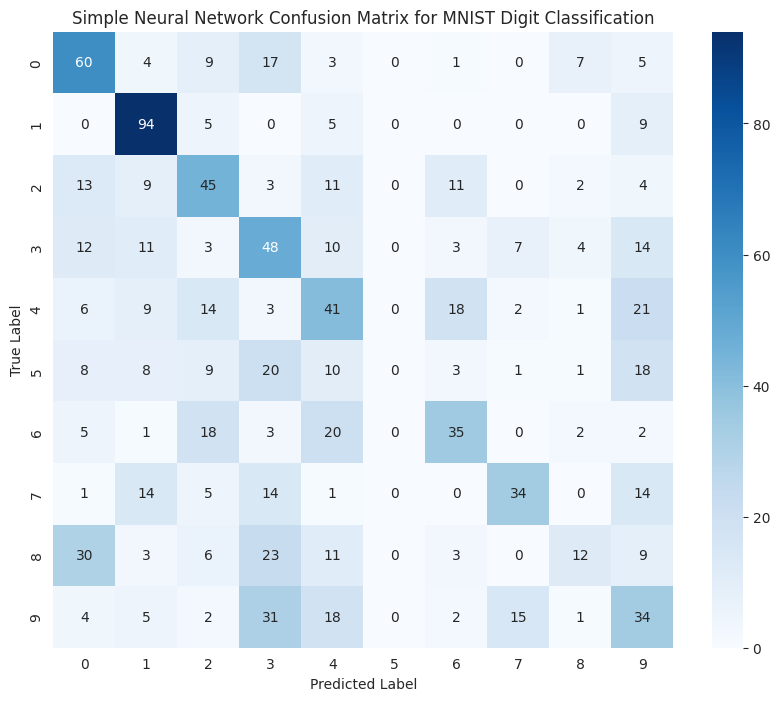

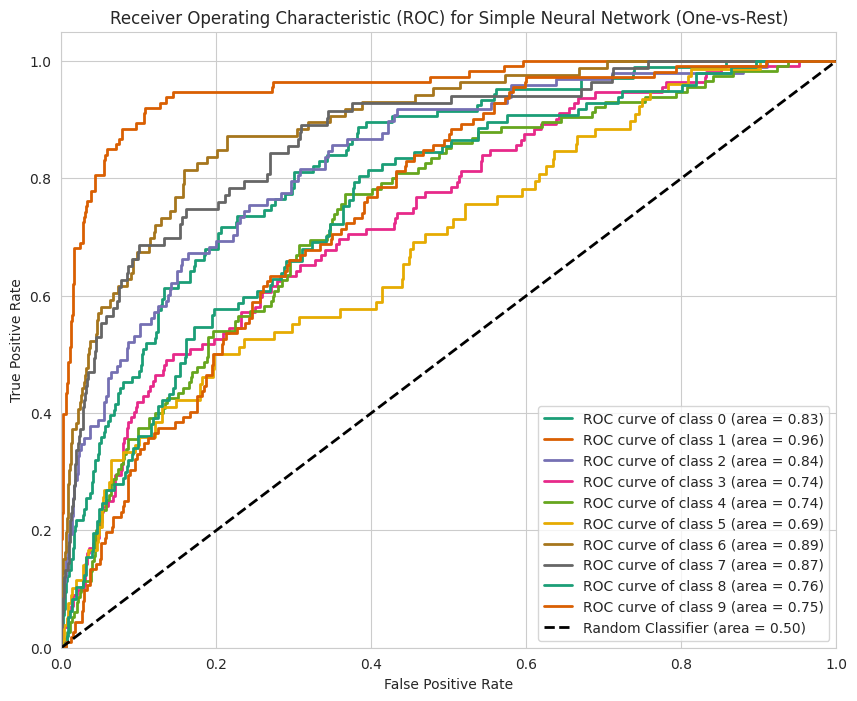


AUC for each class (Simple Neural Network):
Class 0: 0.83
Class 1: 0.96
Class 2: 0.84
Class 3: 0.74
Class 4: 0.74
Class 5: 0.69
Class 6: 0.89
Class 7: 0.87
Class 8: 0.76
Class 9: 0.75


In [227]:
# Make predictions (probabilities) and get predicted classes from the trained Neural Network model
nn_pred_probs = model_nn.predict(X)
nn_predictions = np.argmax(nn_pred_probs, axis=1)

# Print Classification Report for Simple Neural Network
print("\nSimple Neural Network Classification Report:")
print(classification_report(y_encoded, nn_predictions, target_names=[str(i) for i in range(digit_label_cardinality)]))

# Calculate and print Confusion Matrix for Simple Neural Network
nn_cm = confusion_matrix(y_encoded, nn_predictions, labels=range(digit_label_cardinality))
print("\nSimple Neural Network Confusion Matrix:")
print(nn_cm)

# Visualize the Confusion Matrix for Simple Neural Network
plt.figure(figsize=(10, 8))
sns.heatmap(nn_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(digit_label_cardinality),
            yticklabels=range(digit_label_cardinality))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Simple Neural Network Confusion Matrix for MNIST Digit Classification')
plt.show()

# Calculate and plot ROC AUC for Simple Neural Network (One-vs-Rest)
# y_encoded is already binarized implicitly for ROC in this context with to_categorical
# Use y_one_hot which was created from y_encoded

fpr_nn = dict()
tpr_nn = dict()
roc_auc_nn = dict()

plt.figure(figsize=(10, 8))
# Get a distinct color palette for the ROC curves
colors_nn = sns.color_palette('Dark2', digit_label_cardinality) # Changed palette to 'Dark2'

for i in range(digit_label_cardinality):
    fpr_nn[i], tpr_nn[i], _ = roc_curve(y_one_hot[:, i], nn_pred_probs[:, i]) # Calculate FPR, TPR
    roc_auc_nn[i] = auc(fpr_nn[i], tpr_nn[i]) # Calculate AUC
    plt.plot(fpr_nn[i], tpr_nn[i], lw=2, label=f'ROC curve of class {i} (area = {roc_auc_nn[i]:.2f})', color=colors_nn[i]) # Plot ROC curve

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier (area = 0.50)') # Plot random classifier baseline
plt.xlim([0.0, 1.0]) # Set x-axis limits
plt.ylim([0.0, 1.05]) # Set y-axis limits
plt.xlabel('False Positive Rate') # Set x-axis label
plt.ylabel('True Positive Rate') # Set y-axis label
plt.title('Receiver Operating Characteristic (ROC) for Simple Neural Network (One-vs-Rest)') # Set plot title
plt.legend(loc="lower right") # Display legend
plt.grid(True) # Add grid
plt.show() # Display the plot

print("\nAUC for each class (Simple Neural Network):")
for i in range(digit_label_cardinality):
    print(f"Class {i}: {roc_auc_nn[i]:.2f}")